# IPrint News Recommendation Ranking Systems

In [102]:
import warnings
warnings.filterwarnings("ignore")

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
from pathlib import Path

In [114]:
consumer = pd.read_csv("D:\iPrint-News-Recommendation-Ranking-System\Dataset\consumer_transanctions.csv")

In [115]:
content = pd.read_csv("D:\iPrint-News-Recommendation-Ranking-System\Dataset\platform_content.csv")

In [116]:
print("Consumer transactions:", consumer.shape)
print("Platform content:", content.shape)

Consumer transactions: (72312, 8)
Platform content: (3122, 13)


In [117]:
# missing values analysis
def missing_report(df):
    report = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percentage": (
            df.isna().mean() * 100
        ).round(2),
        "unique_values": df.nunique()
    })

    return report.sort_values(
        "missing_percentage",
        ascending=False
    )

In [118]:
print("Consumer Data", consumer_data.shape)
display(missing_report(consumer))

Consumer Data (72312, 8)


,missing_count,missing_percentage,unique_values
consumer_location,15405,21.30,71
consumer_device_info,15394,21.29,1090
country,15394,21.29,23
event_timestamp,0,0.00,68772
interaction_type,0,0.00,5
item_id,0,0.00,2987
consumer_id,0,0.00,1895
consumer_session_id,0,0.00,28909


In [119]:
print("Platform Content")
display(missing_report(content))

Platform Content


,missing_count,missing_percentage,unique_values
producer_device_info,2442,78.22,114
producer_location,2442,78.22,19
producer_country,2442,78.22,5
event_timestamp,0,0.00,3121
interaction_type,0,0.00,2
item_id,0,0.00,3057
producer_id,0,0.00,252
producer_session_id,0,0.00,2017
item_type,0,0.00,3
item_url,0,0.00,3029


In [120]:
# ============================================================
# Duplicate Analysis
# ============================================================

print("Exact duplicate consumer rows:")
print(consumer.duplicated().sum())

print("Exact duplicate content rows:")
print(content.duplicated().sum())

Exact duplicate consumer rows:
11
Exact duplicate content rows:
0


In [121]:
# ------------------------------------------------------------
# Duplicate User-Article interactions
# ------------------------------------------------------------
user_item_duplicates = consumer.duplicated(subset=["consumer_id", "item_id"]).sum()

In [122]:
print("Repeated consumer-item interactions:",user_item_duplicates)

Repeated consumer-item interactions: 31602


In [123]:
print("Repeated interaction percentage:",round(user_item_duplicates / len(consumer) * 100,2),"%")

Repeated interaction percentage: 43.7 %


In [124]:
# Same user + same item + same interaction type
user_item_type_duplicates = consumer.duplicated(subset=["consumer_id","item_id","interaction_type"]).sum()

In [125]:
print("Repeated user-item-interaction events:", user_item_type_duplicates)

Repeated user-item-interaction events: 21374


In [126]:
# ============================================================
# User Activity Distribution
# ============================================================
user_activity = (consumer.groupby("consumer_id").agg(
    total_interactions=("item_id", "size"),
    unique_articles=("item_id", "nunique"),
    unique_sessions=("consumer_session_id", "nunique")).sort_values(
    "total_interactions",ascending=False))

display(user_activity.describe(percentiles=[0.50,0.75,0.90,0.95,0.99]))

,total_interactions,unique_articles,unique_sessions
count,1895.000000,1895.000000,1895.000000
mean,38.159367,21.482850,15.255409
std,104.143355,52.307036,23.729428
min,1.000000,1.000000,1.000000
50%,10.000000,6.000000,6.000000
75%,32.000000,19.000000,18.000000
90%,88.000000,46.000000,40.000000
95%,155.600000,86.000000,59.000000
99%,458.160000,257.240000,113.120000
max,1885.000000,961.000000,232.000000


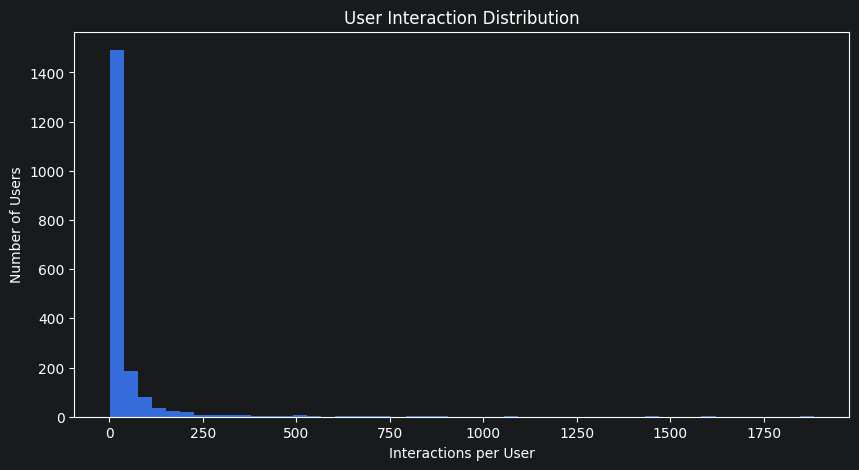

In [127]:
plt.figure(figsize=(10, 5))
plt.hist(user_activity["total_interactions"],bins=50)
plt.xlabel("Interactions per User")
plt.ylabel("Number of Users")
plt.title("User Interaction Distribution")
plt.show()

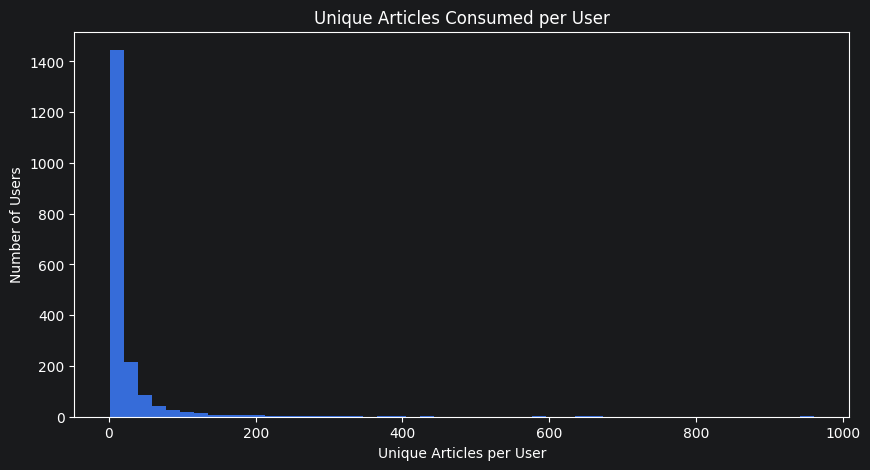

In [128]:
plt.figure(figsize=(10, 5))
plt.hist(user_activity["unique_articles"], bins=50)
plt.xlabel("Unique Articles per User")
plt.ylabel("Number of Users")
plt.title("Unique Articles Consumed per User")
plt.show()

In [129]:
# ============================================================
# Article Popularity
# ============================================================
article_popularity = (consumer.groupby("item_id").agg(total_interactions=("consumer_id", "size"),
                                                      unique_users=("consumer_id", "nunique")).sort_values("total_interactions",ascending=False))
display(article_popularity.describe(percentiles=[0.50,0.75,0.90,0.95,0.99]))

,total_interactions,unique_users
count,2987.000000,2987.000000
mean,24.208905,13.629059
std,32.448298,17.151984
min,1.000000,1.000000
50%,14.000000,9.000000
75%,30.000000,17.000000
90%,54.000000,30.000000
95%,80.000000,43.000000
99%,161.560000,79.280000
max,433.000000,268.000000


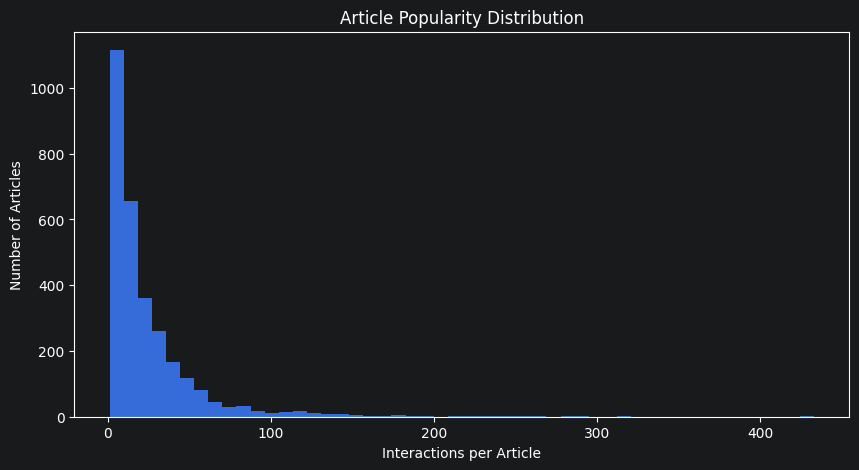

In [130]:
plt.figure(figsize=(10, 5))
plt.hist(article_popularity["total_interactions"],bins=50)
plt.xlabel("Interactions per Article")
plt.ylabel("Number of Articles")
plt.title("Article Popularity Distribution")
plt.show()

In [131]:
# ============================================================
# Popularity Concentration
# ============================================================
popularity = (article_popularity["total_interactions"].sort_values(ascending=False).reset_index(drop=True))
total_interactions = popularity.sum()
for k in [1, 5, 10, 20, 50, 100]:
    top_k_interactions = popularity.head(k).sum()
    percentage = (top_k_interactions / total_interactions * 100)
    print("Top {k} articles account for  {percentage:.2f}% of interactions")

Top {k} articles account for  {percentage:.2f}% of interactions
Top {k} articles account for  {percentage:.2f}% of interactions
Top {k} articles account for  {percentage:.2f}% of interactions
Top {k} articles account for  {percentage:.2f}% of interactions
Top {k} articles account for  {percentage:.2f}% of interactions
Top {k} articles account for  {percentage:.2f}% of interactions


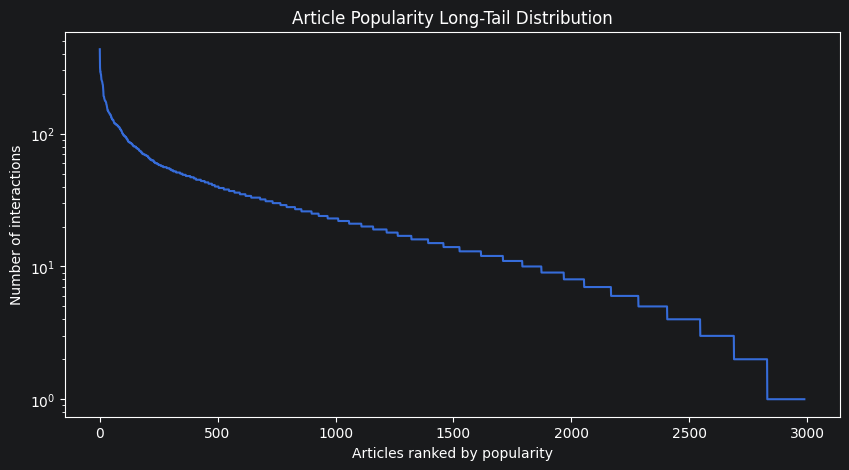

In [132]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(popularity) + 1),popularity.values)
plt.xlabel("Articles ranked by popularity")
plt.ylabel("Number of interactions")
plt.title("Article Popularity Long-Tail Distribution")
plt.yscale("log")
plt.show()

In [133]:
# ============================================================
# User-Item Matrix Sparsity
# ============================================================
n_users = consumer["consumer_id"].nunique()
n_items = consumer["item_id"].nunique()
unique_user_item_pairs = (consumer[["consumer_id", "item_id"]].drop_duplicates().shape[0])
possible_interactions = n_users * n_items
density = (unique_user_item_pairs / possible_interactions)
sparsity = 1 - density
print("Users:", n_users)
print("Items:", n_items)
print("Possible user-item pairs:", possible_interactions)
print("Observed user-item pairs:", unique_user_item_pairs)
print(f"Density: {density:.6f}")
print(f"Sparsity: {sparsity:.6%}")

Users: 1895
Items: 2987
Possible user-item pairs: 5660365
Observed user-item pairs: 40710
Density: 0.007192
Sparsity: 99.280788%


In [134]:
# ============================================================
# New / Low-Activity Users
# ============================================================
user_counts = (consumer.groupby("consumer_id").size())
print("Users with exactly 1 interaction:")
print((user_counts == 1).sum())
print("Users with <= 3 interactions:")
print((user_counts <= 3).sum())
print("Users with <= 5 interactions:")
print((user_counts <= 5).sum())

Users with exactly 1 interaction:
180
Users with <= 3 interactions:
482
Users with <= 5 interactions:
675


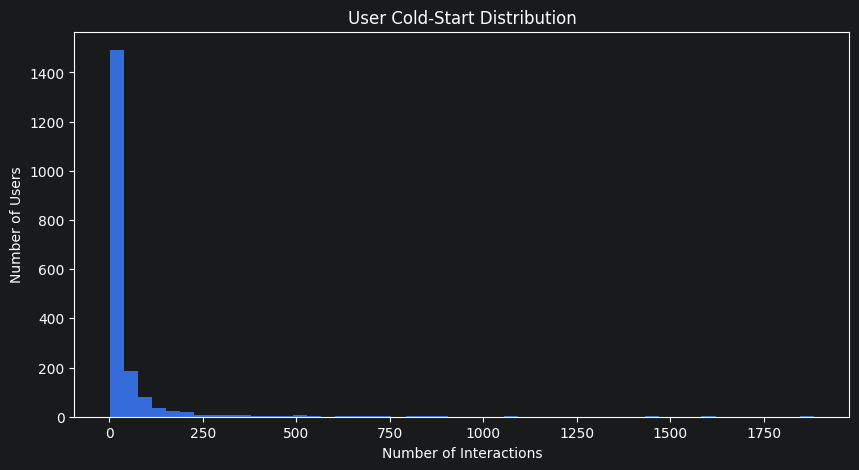

In [135]:
plt.figure(figsize=(10, 5))
plt.hist(user_counts,bins=50)
plt.xlabel("Number of Interactions")
plt.ylabel("Number of Users")
plt.title("User Cold-Start Distribution")
plt.show()

In [136]:
# ============================================================
# Article Cold-Start
# ============================================================
item_counts = (consumer.groupby("item_id").size())
print("Articles with exactly 1 interaction:")
print((item_counts == 1).sum())
print("Articles with <= 3 interactions:")
print((item_counts <= 3).sum())
print("Articles with <= 5 interactions:")
print((item_counts <= 5).sum())

Articles with exactly 1 interaction:
158
Articles with <= 3 interactions:
442
Articles with <= 5 interactions:
704


In [137]:
# ============================================================
# Timestamp Processing
# ============================================================
consumer["event_datetime"] = pd.to_datetime(consumer["event_timestamp"],unit="s",utc=True)
content["event_datetime"] = pd.to_datetime(content["event_timestamp"],unit="s",utc=True)
print("Consumer interaction period:",consumer["event_datetime"].min(),"→",consumer["event_datetime"].max())
print("Content event period:",content["event_datetime"].min(),"→",content["event_datetime"].max())

Consumer interaction period: 2016-03-14 13:54:36+00:00 → 2017-02-28 19:21:51+00:00
Content event period: 2016-03-28 19:19:39+00:00 → 2017-02-28 18:51:11+00:00


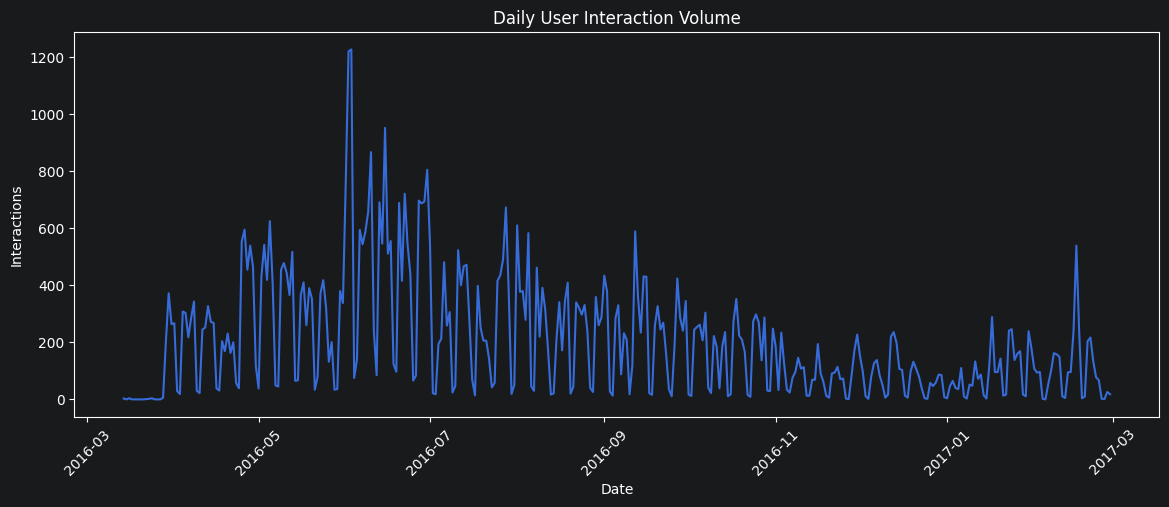

In [138]:
# ============================================================
# Daily Interaction Trend
# ============================================================
daily_interactions = (consumer.set_index("event_datetime").resample("D").size())
plt.figure(figsize=(14, 5))
plt.plot(daily_interactions.index,daily_interactions.values)
plt.xlabel("Date")
plt.ylabel("Interactions")
plt.title("Daily User Interaction Volume")
plt.xticks(rotation=45)
plt.show()

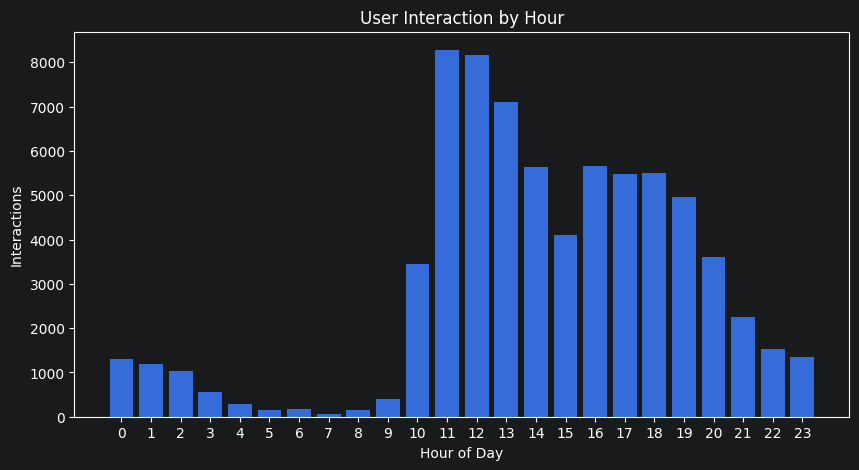

In [139]:
consumer["hour"] = (consumer["event_datetime"].dt.hour)
hourly_interactions = (consumer["hour"].value_counts().sort_index())
plt.figure(figsize=(10, 5))
plt.bar(hourly_interactions.index,hourly_interactions.values)
plt.xlabel("Hour of Day")
plt.ylabel("Interactions")
plt.title("User Interaction by Hour")
plt.xticks(range(24))
plt.show()